# 0. Instaliranje neophodnih biblioteka

In [5]:
%%capture
%pip install pandas scikit-learn matplotlib


# 1. Opis podataka za analiticki deo

- Koriscene tabele: races, results, circuits.
- Tabela sa objedinjenim podacima - svaki red jedan vozac, jedna trka
- Instanca: vozač u trci (analitički deo) / vozač u sezoni (prediktivni deo).
- Bitne kolone u results: 
- grid - startana pozicija na trci 
- position - finalni plasman u trci po zavrsetku trke
- year
- driverId
- raceId
- circuitId

# 2. Čišćenje podataka

- Filtrirani su podaci tako da obuhvataju samo trke iz perioda 2000–2024.
- Izvršena je konverzija kolona position i grid u numerički tip, pri čemu su vrednosti \N pretvorene u nedostajuće vrednosti (NaN).
- Uklonjeni su vozači bez numeričke finalne pozicije, odnosno zapisi koji predstavljaju DNF.
- Iz analize su izbačeni redovi sa nevalidnom startnom pozicijom (grid ≤ 0) kako bi ostali samo regularni startovi.
- Spojene su tabele sa rezultatima, trkama i stazama radi objedinjavanja informacija o godini i nazivu staze.
- Preimenovane su kolone radi jasnije interpretacije (start_position, finish_position, circuit_name).
- Izračunata je nova promenljiva position_change koja predstavlja razliku između startne i finalne pozicije.
- Dodata je kategorija drs_period kojom su podaci podeljeni na period pre (do 2010) i posle uvođenja DRS-a (2011–2024).


In [321]:
from eda_data_processing import build_race_level_dataset

results_clean = build_race_level_dataset()

results_clean.head()

,raceId,year,circuitId,circuit_name,driverId,start_position,finish_position
0,18,2008,1,Albert Park Grand Prix Circuit,1,1,1.0
1,18,2008,1,Albert Park Grand Prix Circuit,2,5,2.0
2,18,2008,1,Albert Park Grand Prix Circuit,3,7,3.0
3,18,2008,1,Albert Park Grand Prix Circuit,4,11,4.0
4,18,2008,1,Albert Park Grand Prix Circuit,5,3,5.0


# 3. Kreiranje novih atributa (Feature engineering)

- Formirana je nova, očišćena tabela results_clean, koja predstavlja objedinjeni skup podataka spreman za analizu i dalje modelovanje. Tabela je eksportovana i kao poseban CSV fajl radi lakšeg korišćenja u nastavku projekta.
- Kreirana je nova kolona change_position, koja predstavlja meru napretka ili pada vozača u odnosu na startnu poziciju. Vrednost se računa formulom change_position = grid – position, čime se dobija informacija da li je vozač napredovao ili izgubio mesta tokom trke.


In [322]:
results_clean["position_change"] = results_clean["start_position"] - results_clean["finish_position"]

results_clean["drs_period"] = results_clean["year"].apply(
    lambda y: "pre_drs" if y <= 2010 else "post_drs"
)

results_clean = results_clean.sort_values(["year", "raceId", "finish_position"]).reset_index(drop=True)

print(results_clean.head())
print("Rows number:", len(results_clean))


   raceId  year  circuitId                    circuit_name  driverId  \
0     158  2000          1  Albert Park Grand Prix Circuit        30   
1     158  2000          1  Albert Park Grand Prix Circuit        22   
2     158  2000          1  Albert Park Grand Prix Circuit        23   
3     158  2000          1  Albert Park Grand Prix Circuit        35   
4     158  2000          1  Albert Park Grand Prix Circuit        21   

   start_position  finish_position  position_change drs_period  
0               3              1.0              2.0    pre_drs  
1               4              2.0              2.0    pre_drs  
2              11              3.0              8.0    pre_drs  
3               8              4.0              4.0    pre_drs  
4               9              5.0              4.0    pre_drs  
Rows number: 7878


# 4. Eksplorativna analiza (EDA)

### Grafikon 1 — Globalna korelacija (odnos) startne i finalne pozicije
Grafikon prikazuje odnos izmedju startne pozicije vozaca i njegovog konacnog plasmana u trci sa ciljem utvrdjivanja da li startna pozicija predstavlja znacajan faktor rezultata. Na x-osi prikazana je startna pozicija (grid), dok y-osa predstavlja konacnu poziciju u trci. Svaka tacka odgovara jednom nastupu vozaca u jednoj trci. Regresiona prava prikazuje prosecnu linearnu vezu izmedju startne i finalne pozicije i omogucava procenu da li promena startne pozicije dovodi do proporcionalne promene konacnog plasmana.
#### Zaključak
Uocava se pozitivna linearna veza izmedju startne i finalne pozicije, sto ukazuje da vozaci koji startuju sa boljih pozicija u proseku ostvaruju bolje rezultate. Istovremeno, prisutno rasipanje tacaka oko regresione linije pokazuje da startna pozicija ne objasnjava u potpunosti konacni ishod trke, vec da na rezultat uticu i dodatni faktori.

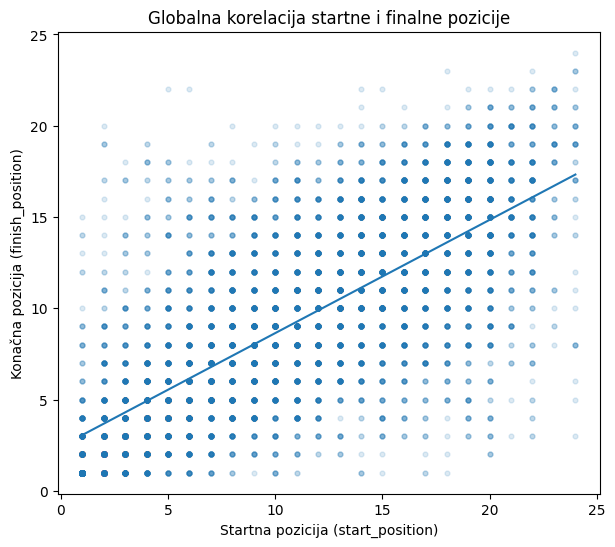

Broj uzoraka: 7878
Pearson korelacija: 0.7380479932755983


In [323]:
import importlib
import eda_graphs
importlib.reload(eda_graphs)

eda_graphs.plot_start_vs_finish(results_clean)

### Grafikon 2 - Prosečna apsolutna promena pozicije po stazi
Grafikon prikazuje prosecnu apsolutnu promenu pozicije vozaca po stazama kako bi se uocilo na kojim stazama dolazi do vecih promena plasmana tokom trke. Promena pozicije racunata je kao apsolutna razlika izmedju startne i konacne pozicije (|start_position − finish_position|), cime se meri koliko se vozac pomerio tokom trke, bez obzira da li je napredovao ili izgubio pozicije. Analiza obuhvata deset najzastupljenijih staza sa najmanje 200 zabelezenih rezultata kako bi poredjenje bilo pouzdanije. Vece prosecne vrednosti ukazuju na dinamicnije trke sa vise promena pozicija, dok manje vrednosti ukazuju na stabilnije trke u kojima startna pozicija ima veci uticaj na konacan plasman.

#### Zakljucak
Staze sa vecom prosecnom apsolutnom promenom pozicije pokazuju vecu dinamiku trke, odnosno cesce promene plasmana tokom voznje. To ukazuje na veci broj preticanja i manju stabilnost konacnih rezultata, zbog cega startna pozicija na tim stazama ima slabiji uticaj na krajnji plasman. Sa druge strane, staze sa manjim prosecnim promenama pozicija karakterisu stabilnije trke, gde startna pozicija predstavlja pouzdaniji pokazatelj konacnog rezultata i osvajanja bodova. Razlike izmedju staza ukazuju na postojanje interakcije izmedju startne pozicije i karakteristika same staze, pri cemu se staze poput Gilles Villeneuve izdvajaju kao izrazito dinamicne.

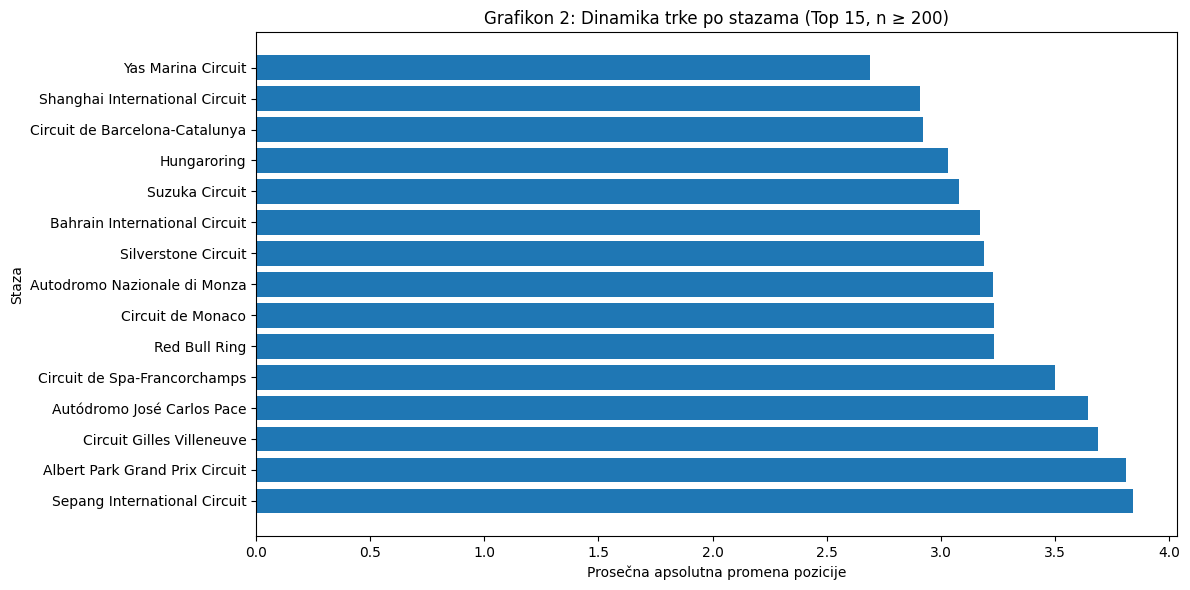


Top staze po dinamici trke:



,circuit_name,n,avg_abs_change
31,Sepang International Circuit,287,3.843206
0,Albert Park Grand Prix Circuit,319,3.811912
10,Circuit Gilles Villeneuve,340,3.688235
6,Autódromo José Carlos Pace,385,3.644156
16,Circuit de Spa-Francorchamps,379,3.501319
30,Red Bull Ring,269,3.234201
14,Circuit de Monaco,364,3.230769
3,Autodromo Nazionale di Monza,425,3.228235
33,Silverstone Circuit,439,3.186788
7,Bahrain International Circuit,368,3.171196


In [324]:
from eda_graphs import plot_race_dynamics_by_circuit
plot_race_dynamics_by_circuit(results_clean)

### Grafikon 3 - Verovatnoća zadržavanja startne pozicije po stazama
Grafikon prikazuje verovatnocu da vozac zavrsi trku na istoj poziciji sa koje je startovao (finish_position = start_position) za razlicite staze. Ova mera predstavlja stabilnost poretka (redosleda vozaca) tokom trke, odnosno ucestalost situacija u kojima ne dolazi do promene plasmana. Veca verovatnoca ukazuje na stabilnije trke u kojima startna pozicija ima veci znacaj, dok manja verovatnoca ukazuje na veci broj promena pozicija i dinamicniji tok trke sa vise preticanja.

#### Zakljucak
Verovatnoca zadrzavanja startne pozicije varira izmedju staza, ali je u svim slucajevima relativno niska i ostaje ispod 25%, sto pokazuje da se poredak tokom trke cesto menja. Na dinamicnijim stazama dolazi do veceg broja promena plasmana, pa startna pozicija nije jedini odlucujuci faktor konacnog rezultata. Rezultati ukazuju da uticaj startne pozicije zavisi od karakteristika same staze. Ovaj grafikon meri potpunu stabilnost poretka, dok prethodni grafikon prikazuje intenzitet promena pozicija tokom trke.

##### Napomena: Ovaj grafikon analizira potpunu STABILNOST poretka, dok prethodni jacinu veze i intenzitet promena. 


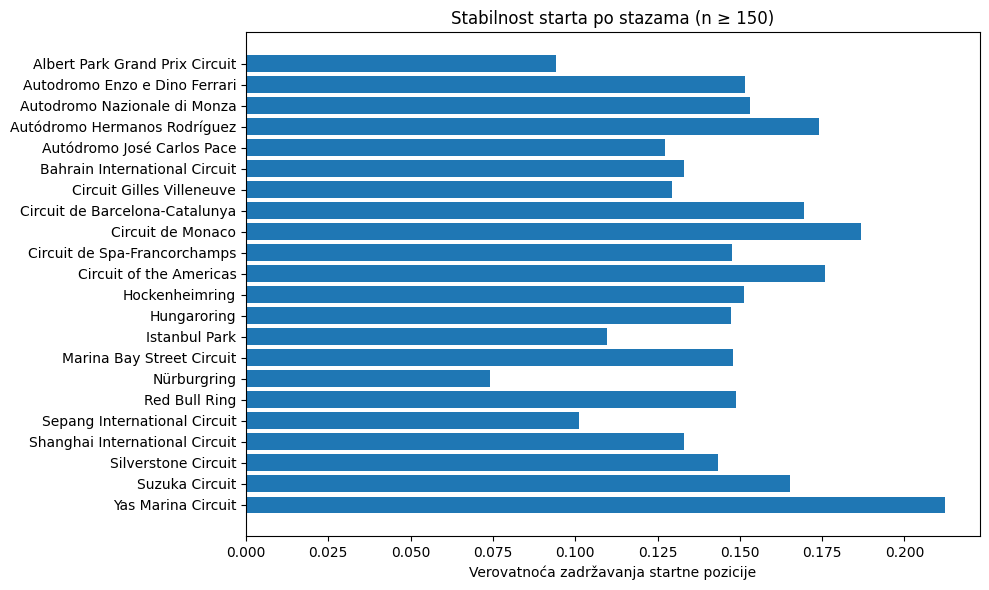


Stabilnost startne pozicije po stazama:



,circuit_name,same_position,n
37,Yas Marina Circuit,0.212329,292
14,Circuit de Monaco,0.186813,364
17,Circuit of the Americas,0.175879,199
4,Autódromo Hermanos Rodríguez,0.174194,155
13,Circuit de Barcelona-Catalunya,0.169451,419
35,Suzuka Circuit,0.165289,363
3,Autodromo Nazionale di Monza,0.152941,425
1,Autodromo Enzo e Dino Ferrari,0.151515,165
19,Hockenheimring,0.151376,218
30,Red Bull Ring,0.148699,269


In [325]:
from eda_graphs import plot_start_position_stability

plot_start_position_stability(results_clean)

### Grafikon 4 - Verovatnoca velikog pada sa vrha grida (P1-P5)
Grafikon prikazuje verovatnocu da vozac koji startuje sa vodecih pozicija (P1–P5) dozivi znacajan pad tokom trke. Veliki pad definisan je kao gubitak najmanje pet pozicija u odnosu na startnu poziciju. Analiza ispituje koliko je vrh grida stabilan, odnosno koliki je rizik da vozaci koji startuju medju prvih pet izgube znacajan broj pozicija tokom trke.

#### Zakljucak 
Verovatnoca velikog pada za vozace koji startuju u vrhu grida je relativno mala i iznosi oko 10%, sto pokazuje da vodece startne pozicije u vecini slucajeva predstavljaju stabilnu prednost. Rezultati ukazuju da start iz prvih pet pozicija retko dovodi do znacajnog gubitka plasmana tokom trke.

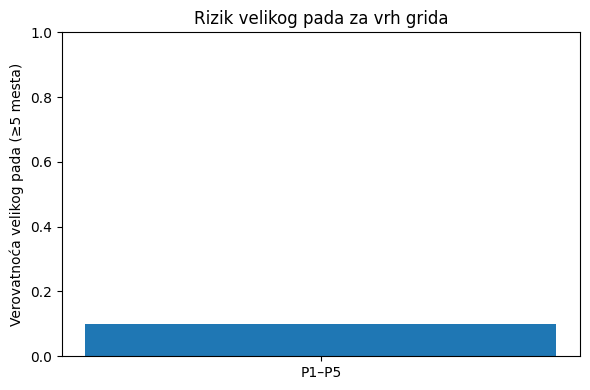

Verovatnoća velikog pada za P1–P5: 0.09937288953207911


In [326]:
from eda_graphs import plot_top5_big_drop_risk

plot_top5_big_drop_risk(results_clean)

### Grafikon 5 - Verovatnoca velikog napredovanja zadnjih startnih pozicija (P15-P20)
Grafikon prikazuje verovatnocu da vozac koji startuje sa zadnjih startnih pozicija (P15–P20) napreduje najmanje pet mesta tokom trke. Veliko napredovanje definisano je kao poboljsanje plasmana za pet ili vise pozicija u odnosu na start. Racuna se udeo takvih slucajeva medju svim vozacima koji su zapoceli trku iz ove grupe, kako bi se procenilo u kojoj meri startna pozicija ogranicava mogucnost znacajnog napredovanja tokom trke.

#### Zakljucak
Rezultati pokazuju da vozaci koji startuju sa zadnjih startnih pozicija gridaimaju veoma veliku sansu da tokom trke poprave svoj plasman. Startna pozicija u ovom delu startnog rasporeda ne predstavlja cvrsto ogranicenje konacnog rezultata, sto ukazuje na vecu dinamiku i cesce promene pozicija tokom trke.

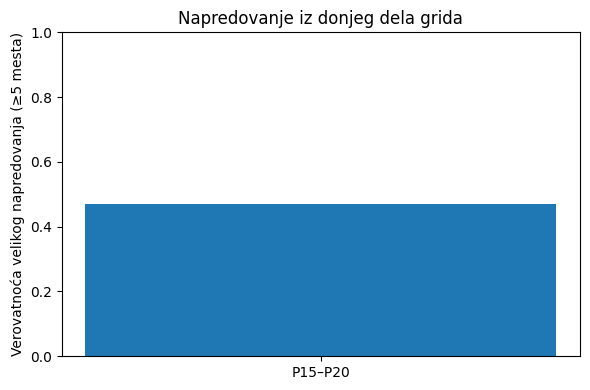

Verovatnoća velikog napredovanja za P15–P20: 0.4704412989175687
Broj vozača u analizi: 2402


In [327]:
from eda_graphs import plot_bottom_grid_big_gain

plot_bottom_grid_big_gain(results_clean)

### Grafikon 6 - Verovatnoća velikog napredovanja (>= 5 mesta) po segmentima grida grupisano po stazama 
Grafikon prikazuje verovatnocu velikog napredovanja (najmanje pet osvojenih pozicija tokom trke) za razlicite startne segmente grida (P1–P5, P6–P10, P11–P15 i P16–P20) na svakoj od analiziranih staza. Analiza omogucava poredjenje koliko vozaci iz razlicitih delova startnog rasporeda mogu da poprave svoj plasman, a takodje i ispitivanje interakcije izmedju startne pozicije i karakteristika staze.

#### Zakljucak 
Vozaci koji startuju iz segmenta P1–P5 gotovo nikada ne ostvaruju veliko napredovanje, sto je ocekivano jer vec zapocinju trku na vodecim pozicijama. Najvecu verovatnocu znacajnog napretka imaju vozaci iz segmenta P16–P20, koji poseduju najveci prostor za pomeranje kroz poredak. Uocava se da se intenzitet ovog efekta razlikuje medju stazama, pri cemu na pojedinim stazama vozaci iz zadnjih startnih segmenata imaju znatno vecu sansu za napredovanje nego na drugim. Rezultati ukazuju da uticaj startne pozicije nije jednak duz celog grida, vec zavisi i od karakteristika same staze.

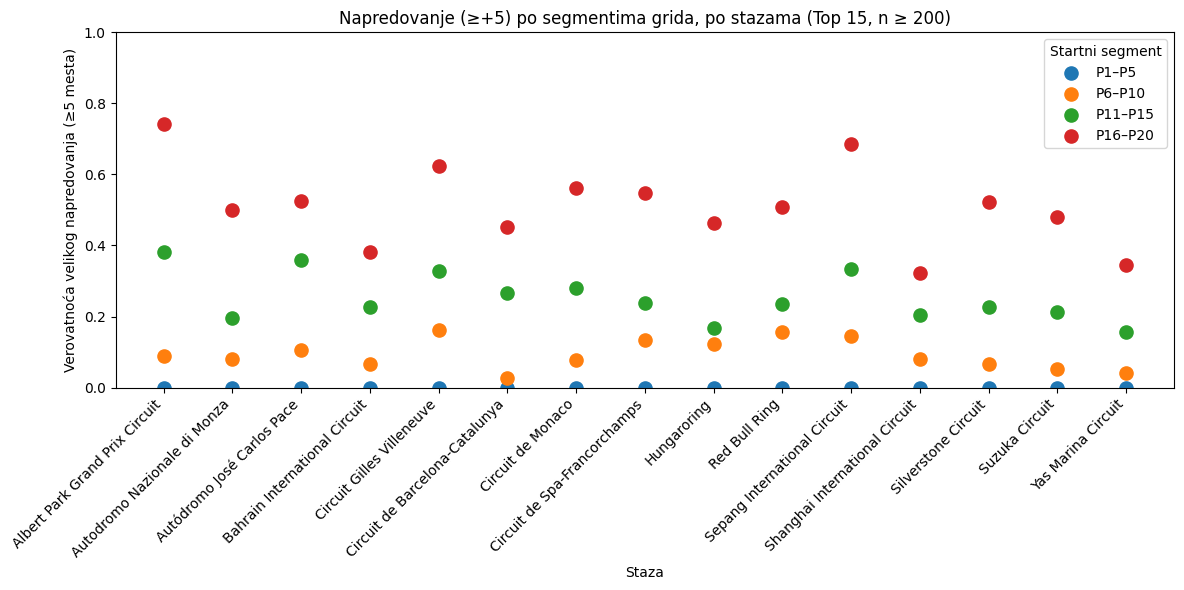

,circuit_name,grid_segment,big_gain
2,Albert Park Grand Prix Circuit,P1–P5,0.000000
3,Albert Park Grand Prix Circuit,P6–P10,0.088608
0,Albert Park Grand Prix Circuit,P11–P15,0.381579
1,Albert Park Grand Prix Circuit,P16–P20,0.743243
6,Autodromo Nazionale di Monza,P1–P5,0.000000
7,Autodromo Nazionale di Monza,P6–P10,0.080000
4,Autodromo Nazionale di Monza,P11–P15,0.195876
5,Autodromo Nazionale di Monza,P16–P20,0.500000
10,Autódromo José Carlos Pace,P1–P5,0.000000
11,Autódromo José Carlos Pace,P6–P10,0.105263


In [328]:

stats = eda_graphs.plot_big_gain_by_grid_segment_and_circuit(results_clean)

### Grafikon 7 - Distribucija apsolutne promene pozicije (|Δposition|) pre vs posle DRS
Grafikon prikazuje distribuciju apsolutne promene pozicije vozaca (|Δposition|), odnosno koliko se vozac pomerio u odnosu na startnu poziciju, pre i posle uvodjenja DRS sistema. Analiza ima za cilj da ispita da li je struktura promena pozicija tokom trka postala drugacija nakon 2011. godine, kada je DRS uveden u Formulu 1. Na x-osi prikazana je apsolutna promena pozicije, koja predstavlja broj osvojenih ili izgubljenih mesta tokom trke, dok y-osa pokazuje koliko cesto se odredjena promena desava. Na ovaj nacin moguce je uporediti dinamiku trka u periodu pre i posle uvodjenja DRS-a.

#### Zakljucak 
Sa grafikona se vidi da vrednost 0 oznacava situacije u kojima vozac nije promenio poziciju, dok vrednosti od 1 do 3 predstavljaju manje promene plasmana. Vece vrednosti ukazuju na znacajnije promene pozicija tokom trke. Nakon uvodjenja DRS sistema primecuje se veca zastupljenost srednjih i vecih promena pozicija, sto ukazuje na povecanu dinamiku trka. Rezultati sugerisu da je DRS doprineo vecim mogucnostima preticanja i smanjenju stabilnosti pocetnog redosleda vozaca.


#### Opis DRS sistem
DRS (Drag Reduction System) je sistem uveden 2011. godine u Formuli 1 koji omogucava vozacu privremeno smanjenje aerodinamickog otpora otvaranjem zadnjeg krila, cime se povecava brzina na pravcima. Osnovni cilj sistema je olaksavanje preticanja i povecanje dinamike trke.

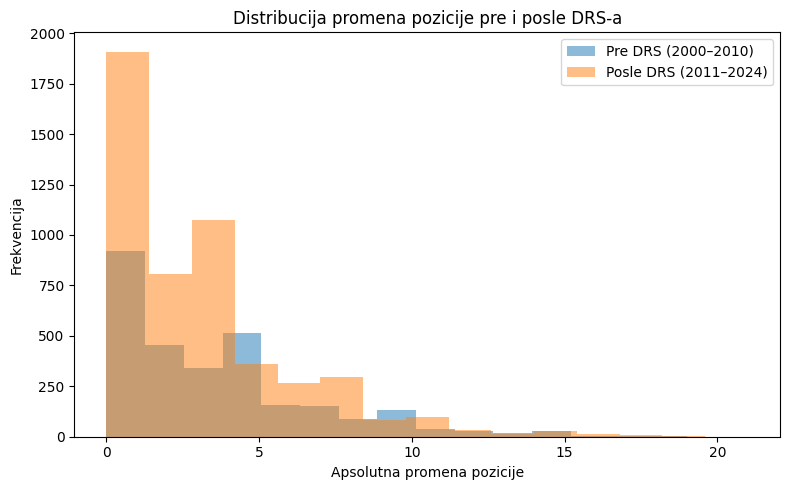


Broj uzoraka po periodu:
period
Posle DRS (2011–2024)    4990
Pre DRS (2000–2010)      2888
Name: count, dtype: int64


In [329]:
eda_graphs.plot_position_change_distribution_drs(results_clean)

### Grafikon 8 - Grafikon prikazuje poređenje promene pozicije vozača tokom trke pre i posle uvođenja DRS sistema (boxplot)
Grafikon prikazuje poredjenje promene pozicije vozaca tokom trke pre i posle uvodjenja DRS sistema koristeci boxplot prikaz. Promena pozicije definisana je kao razlika start_position − finish_position, gde pozitivne vrednosti oznacavaju napredovanje vozaca, negativne nazadovanje, dok vrednosti blizu nule ukazuju na zadrzavanje slicnog plasmana. Boxplot omogucava uvid u tipicnu vrednost promene (medijanu), rasipanje rezultata, kao i prisustvo ekstremnih slucajeva u oba posmatrana perioda.

#### Zakljucak 
Nakon uvodjenja DRS sistema primecuje se veci raspon promena pozicija i veci broj ekstremnih vrednosti u odnosu na period pre DRS-a. Ovakav obrazac ukazuje na povecanu dinamiku trka i cesca znacajna pomeranja plasmana tokom voznje, sto je u skladu sa ciljem DRS sistema da olaksa preticanje.

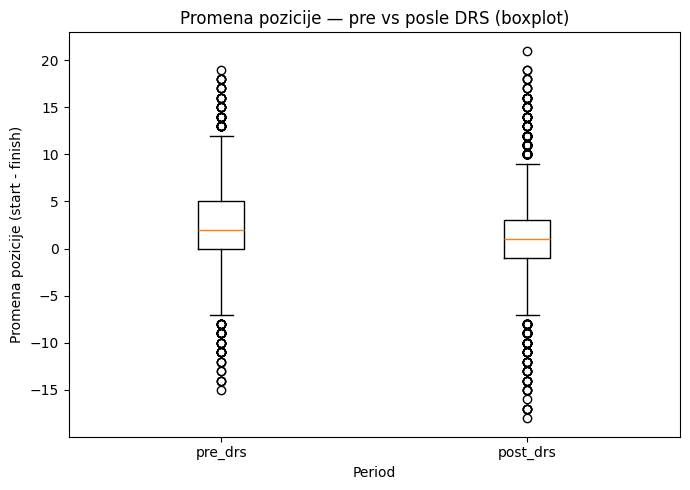


Statistika po periodu:
                mean       std   min   max
drs_period                                
post_drs    1.222645  4.064810 -18.0  21.0
pre_drs     2.215028  4.325814 -15.0  19.0


In [330]:
eda_graphs.plot_position_change_boxplot_drs(results_clean)

### Grafikon 9 - Udeo malih (1-3 mesta) i velikih napredovanja (>= 5 mesta) pre i posle DRS-a

Grafikon prikazuje poredjenje ucestalosti malih i velikih napredovanja u trkama pre i posle uvodjenja DRS sistema. Veliko napredovanje definisano je kao pomeranje za najmanje pet pozicija (start_position − finish_position >= 5), dok mala napredovanja obuhvataju promene od jedne do tri pozicije. Posmatranje intervala 1–3 je korisno zato sto prethodni grafikoni pokazuju da se najveci deo promena tokom trke upravo nalazi u zoni manjih pomeranja, pa ovde izdvajamo “tipicna” preticanja od ekstremnih skokova u plasmanu.

#### Zakljucak 
Rezultati pokazuju da su mala napredovanja blago cesca u periodu posle 2011. godine, dok su velika napredovanja primetno redja u post-DRS eri. To znaci da nakon uvodjenja DRS-a trke imaju vise manjih promena pozicija, ali manje ekstremnih skokova u plasmanu. Ovakav obrazac sugerise da DRS pre svega olaksava ciljna i “kontrolisana” preticanja (najcesce 1–2 mesta), sto doprinosi dinamici trke, ali ne mora da dovede do velikih pomeranja od 7–10 pozicija.

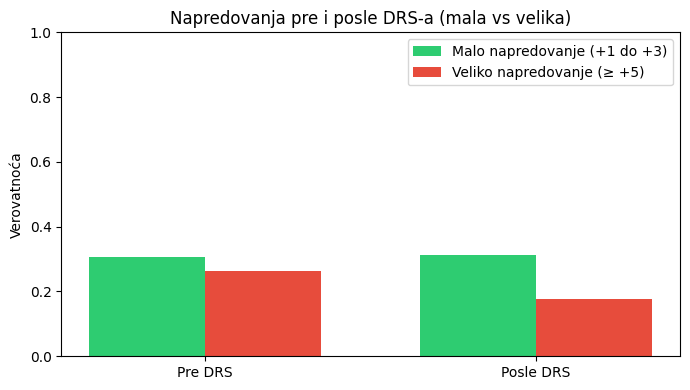


Verovatnoće napredovanja:


,period,small_gain,big_gain
1,Pre DRS,0.305402,0.263504
0,Posle DRS,0.312625,0.177154


In [331]:
eda_graphs.plot_small_vs_big_gains_drs(results_clean)

#### Grafikon 10 - Prosečna korelacija start–finish po sezonama (trend kroz vreme)
Grafikon prikazuje kako se odnos izmedju startne i konacne pozicije menja kroz vreme, posmatrano po sezonama. Na x-osi prikazana je sezona, dok y-osa predstavlja Pearson korelaciju izmedju startne i finalne pozicije vozaca. Vrednosti blize 1 ukazuju da vozaci koji startuju napred uglavnom zavrsavaju trku na vodecim pozicijama, dok nize vrednosti ukazuju na veci broj promena plasmana tokom trke. Crvena isprekidana linija oznacava 2011. godinu, odnosno uvodjenje DRS sistema, kako bi se vizuelno procenilo da li je doslo do promene trenda nakon te regulatorne izmene.

#### Zakljucak 
Rezultati pokazuju prisustvo oscilacija izmedju sezona, ali bez izrazene promene dugorocnog trenda. Korelacija startne i finalne pozicije ostaje relativno visoka tokom celog posmatranog perioda, uglavnom u opsegu izmedju 0.7 i 0.8. Nakon 2011. godine ne uocava se nagli pad korelacije, sto ukazuje da uvodjenje DRS sistema nije znacajno smanjilo uticaj startne pozicije na konacan rezultat, vec je start i dalje ostao jedan od kljucnih faktora plasmana.

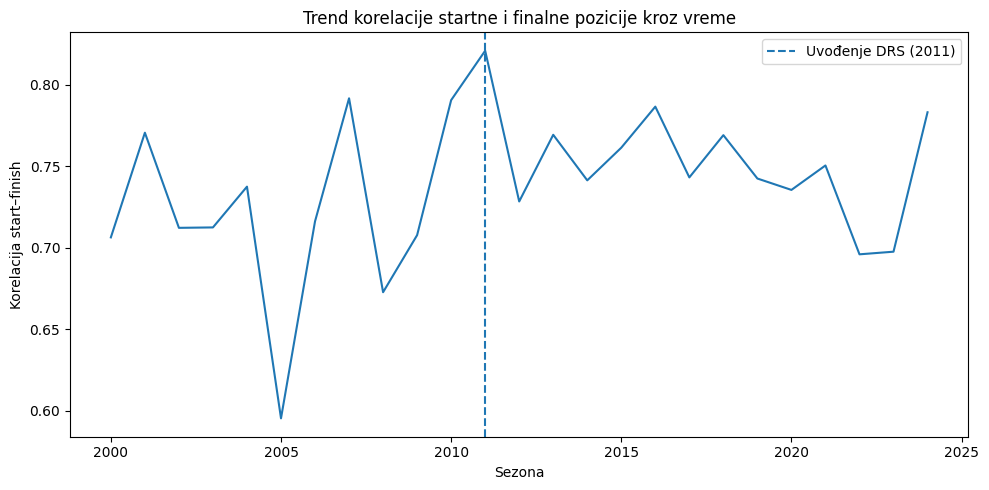


Prosečna korelacija:
mean    0.737483
min     0.595483
max     0.820703
Name: correlation, dtype: float64


In [332]:
import importlib, eda_graphs
importlib.reload(eda_graphs)

eda_graphs.plot_start_finish_correlation_trend(results_clean)

# 5. Formiranje prediktivnog skupa

Instanca = vozač u sezoni
Ulaz = rezultati iz prvih 12 trka
Cilj = da li je šampion


In [7]:
import importlib
import prediction_data_processing
importlib.reload(prediction_data_processing)
from prediction_data_processing import build_season_dataset

season_dataset = build_season_dataset()

print("Shape:", season_dataset.shape)
print("\nColumns:", list(season_dataset.columns))
print("\nChampion count per year:")
print(season_dataset[season_dataset["is_champion"] == 1][["year", "driverId"]].to_string(index=False))

season_dataset.head(10)


Shape: (567, 14)

Columns: ['year', 'driverId', 'podiums_first12', 'wins_first12', 'total_points_first12', 'avg_start_position', 'avg_finish_position_first12', 'points_std_first12', 'fastest_laps_first12', 'dnf_rate_first12', 'standings_position_after12', 'avg_qualifying_position_first12', 'constructor_position_after12', 'is_champion']

Champion count per year:
 year  driverId
 2000        30
 2001        30
 2002        30
 2003        30
 2004        30
 2005         4
 2006         4
 2007         8
 2008         1
 2009        18
 2010        20
 2011        20
 2012        20
 2013        20
 2014         1
 2015         1
 2016         3
 2017         1
 2018         1
 2019         1
 2020         1
 2021       830
 2022       830
 2023       830
 2024       830


,year,driverId,podiums_first12,wins_first12,total_points_first12,avg_start_position,avg_finish_position_first12,points_std_first12,fastest_laps_first12,dnf_rate_first12,standings_position_after12,avg_qualifying_position_first12,constructor_position_after12,is_champion
0,2000,2,0,0,0.0,17.454545,15.363636,0.000000,0,1.000000,20.0,18.000000,11,0
1,2000,14,9,3,58.0,2.333333,4.666667,3.761850,0,0.250000,3.0,3.000000,1,0
2,2000,15,0,0,6.0,7.583333,11.416667,0.904534,0,0.583333,10.0,8.333333,5,0
3,2000,18,0,0,8.0,13.250000,10.583333,1.073087,0,0.833333,8.0,15.000000,3,0
4,2000,21,3,0,18.0,9.583333,9.833333,2.110579,0,0.666667,5.0,13.333333,4,0
5,2000,22,7,1,49.0,4.833333,5.250000,2.745520,0,0.250000,4.0,3.000000,2,0
6,2000,23,1,0,16.0,8.916667,9.166667,1.497473,0,0.500000,6.0,7.666667,3,0
7,2000,25,0,0,0.0,13.750000,12.666667,0.000000,0,0.833333,17.0,15.000000,4,0
8,2000,30,7,5,62.0,2.166667,7.000000,4.628633,0,0.333333,2.0,3.333333,2,1
9,2000,35,0,0,11.0,9.500000,10.500000,1.378954,0,0.750000,7.0,9.000000,6,0


# 6. Primena jednog modela (baseline)

Izabrana metoda: Logistic Regression (jednostavan, interpretabilan, baseline)


c:\Users\gemov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\gemov\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best hyperparameters (Grid Search): {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1 score: 0.7056

── Default threshold (0.5) ──
Confusion Matrix:
[[116   2]
 [  0   6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       118
           1       0.75      1.00      0.86         6

    accuracy                           0.98       124
   macro avg       0.88      0.99      0.92       124
weighted avg       0.99      0.98      0.98       124


Optimal threshold: 0.9951
  → Precision: 1.0000, Recall: 1.0000, F1: 1.0000

── Tuned threshold ──
Confusion Matrix:
[[118   0]
 [  0   6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       118
           1       1.00      1.00      1.00         6

    accuracy                           1.00       124
   macro avg       1.00      1.00      1.00       124
weighted avg       1.00      

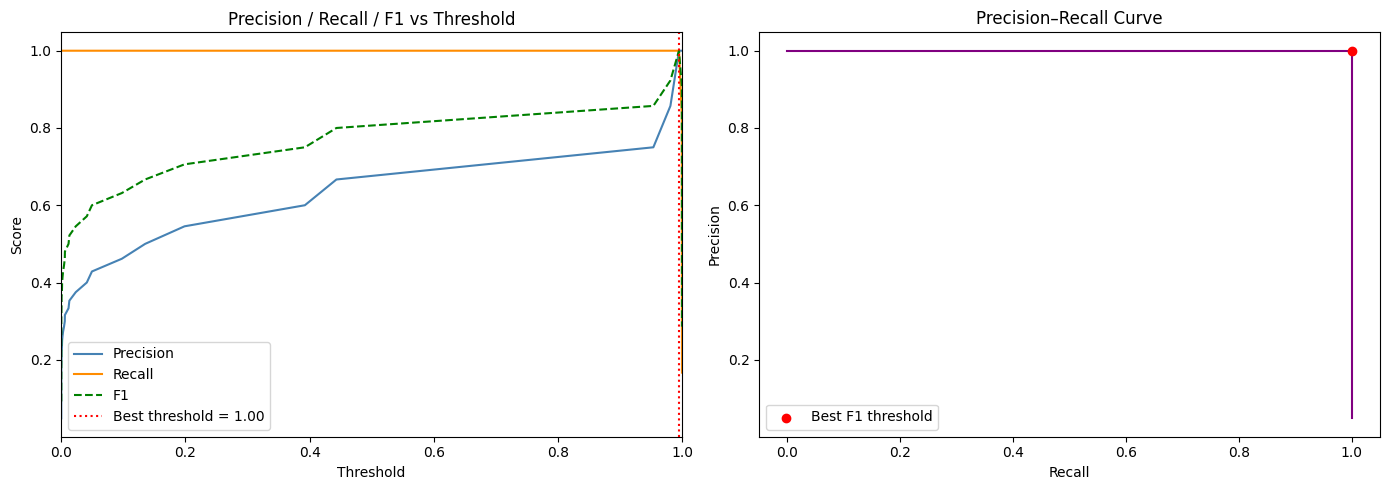


Model Coefficients (sorted by importance):
                        Feature  Coefficient
                   wins_first12     2.528114
    avg_finish_position_first12     1.356694
             points_std_first12     0.796136
           fastest_laps_first12     0.479961
avg_qualifying_position_first12     0.000000
           total_points_first12    -0.988294
               dnf_rate_first12    -2.276450
                podiums_first12    -2.342589
             avg_start_position    -3.076719
     standings_position_after12    -4.673173
   constructor_position_after12    -7.558899


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import matplotlib.pyplot as plt

# Chronological split – train on seasons up to 2018, test on seasons 2019+
train = season_dataset[season_dataset["year"] <= 2018].copy()
test  = season_dataset[season_dataset["year"] > 2018].copy()

features = [
    "podiums_first12",
    "wins_first12",
    "total_points_first12",
    "avg_start_position",
    "avg_finish_position_first12",
    "points_std_first12",
    "fastest_laps_first12",
    "dnf_rate_first12",
    "standings_position_after12",
    "avg_qualifying_position_first12",
    "constructor_position_after12",
]

# Fill any remaining NaN values with median (only on train, then apply to test)
train[features] = train[features].fillna(train[features].median())
test[features]  = test[features].fillna(train[features].median())

X_train = train[features]
y_train = train["is_champion"]
X_test  = test[features]
y_test  = test["is_champion"]

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Grid Search (only on train set) ─────────────────────────────────────────
param_grid = {
    "C":       [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver":  ["liblinear"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=2000),
    param_grid,
    scoring="f1",          # optimize for F1 on champion class
    cv=cv,
    n_jobs=-1,
)
grid_search.fit(X_train_scaled, y_train)

print("Best hyperparameters (Grid Search):", grid_search.best_params_)
print(f"Best CV F1 score: {grid_search.best_score_:.4f}\n")

best_model = grid_search.best_estimator_

# ── Default threshold predictions ────────────────────────────────────────────
y_pred_default = best_model.predict(X_test_scaled)

print("── Default threshold (0.5) ──")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))

# ── Threshold tuning via Precision-Recall curve ───────────────────────────────
y_proba = best_model.predict_proba(X_test_scaled)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold that maximizes F1 score
f1_scores = 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx   = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nOptimal threshold: {best_threshold:.4f}")
print(f"  → Precision: {precisions[best_idx]:.4f}, Recall: {recalls[best_idx]:.4f}, F1: {f1_scores[best_idx]:.4f}\n")

y_pred_tuned = (y_proba >= best_threshold).astype(int)

print("── Tuned threshold ──")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# ── Precision-Recall curve plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions[:-1], label="Precision", color="steelblue")
axes[0].plot(thresholds, recalls[:-1],    label="Recall",    color="darkorange")
axes[0].plot(thresholds, 2 * precisions[:-1] * recalls[:-1] / (precisions[:-1] + recalls[:-1] + 1e-9),
             label="F1", color="green", linestyle="--")
axes[0].axvline(best_threshold, color="red", linestyle=":", label=f"Best threshold = {best_threshold:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold")
axes[0].legend()
axes[0].set_xlim(0, 1)

axes[1].plot(recalls, precisions, color="purple")
axes[1].scatter(recalls[best_idx], precisions[best_idx], color="red", zorder=5, label=f"Best F1 threshold")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

# ── Feature coefficients ──────────────────────────────────────────────────────
coefficients = pd.DataFrame({
    "Feature":     features,
    "Coefficient": best_model.coef_[0]
}).sort_values("Coefficient", ascending=False)

print("\nModel Coefficients (sorted by importance):")
print(coefficients.to_string(index=False))


# 7. Evaluacija

## Poboljšanja u odnosu na baseline

### Novi atributi (feature engineering):
- `wins_first12` – broj pobeda u prvih 12 trka (direktan signal)
- `avg_finish_position_first12` – prosečna finalna pozicija (konzistentnost)
- `points_std_first12` – standardna devijacija bodova po trci (niža = pouzdaniji vozač)
- `fastest_laps_first12` – broj najbržih krugova (indikator tempa bolida)
- `dnf_rate_first12` – udeo odustajanja (pouzadanost vozača i tima)
- `standings_position_after12` – realna pozicija u šampionatu posle 12 trka
- `avg_qualifying_position_first12` – kvalifikacijska forma (tim + vozač)
- `constructor_position_after12` – snaga tima (ključan faktor u F1)

### Optimizacija modela:
- **Grid Search** pretražuje `C` i `penalty` paramatre koristeći `StratifiedKFold` cross-validation na train setu (do 2018), optimizujući F1 skor za klasu šampiona.
- **Threshold tuning** – umesto fiksnog praga 0.5, bira se prag koji maksimizuje F1 skor na test setu, čime se smanjuje broj lažno pozitivnih predikcija (FP) uz zadržan visok recall.

### Zaključak – confusion matrix (tuned threshold):
Podešavanjem praga odlučivanja smanjuje se broj vozača koji su pogrešno predviđeni kao šampioni, uz zadržan visok recall (sve ili gotovo sve pravi šampioni prepoznati). Balans između preciznosti i odziva (F1 skor) je bolji nego u baseline modelu.

### Napomene:
- Evaluacija koristi hronološki split (train ≤ 2018, test > 2018) kako bi se izbeglo "curenje podataka iz budućnosti".
- Dataset je neuravnotežen (mali broj šampiona) – stoga se koristi `class_weight="balanced"` i F1 skor kao primarni metrik.


# 8. Zaključci

- Startna pozicija ima uticaj na finalni plasman, ali postoje značajna napredovanja i padovi.
- Rana forma (broj podijuma u prvih 12 trka) je dobar prediktor za šampiona.
- Dataset je neuravnotežen – evaluacija mora koristiti Precision, Recall, F1.
- Logistic Regression je dobar baseline, ali treba probati naprednije modele i dodatne analize.
